# Reproducibility of a literature-derived miRNA panel for tumour-vs-normal discrimination in two independent breast-cancer cohorts

### A cross-cohort benchmark with explicit null comparators

**Primary question (reframed).**
Does a panel of 15 microRNAs curated from the recent breast-cancer treatment-resistance literature (Gheorghe et al., 2025) show *reproducible tumour-vs-adjacent-normal discrimination* across two independent Agilent miRNA microarray cohorts, **and does it do so beyond what random miRNA panels or single well-known cancer miRNAs would achieve on the same task**?

### What this project is
- A benchmark of a **pre-specified 15-miRNA panel** on a classical, near-trivial endpoint (tumour vs adjacent-normal tissue).
- A **cross-platform reproducibility exercise** between two Agilent designs.
- A demonstration of a defensible external-validation workflow: locked panel, locked model, patient-cluster bootstrap, null benchmarks and calibration.


### Datasets
**Development cohort — GSE45666**
- 101 breast tumours
- 15 adjacent-normal breast samples
- Agilent miRNA array

**Locked external cohort — GSE38167**
- 31 primary TNBC (IDC) samples
- 23 normal-adjacent (NAT) samples
- lymph-node metastases excluded from the primary endpoint
- independent Agilent miRNA design

### Why this design?
The panel is fixed from literature before any model fitting. GSE45666 is development data; GSE38167 is external validation. We add three **null benchmarks** so the reader can tell whether the panel does biological work or simply reflects the ease of the tumour-vs-normal task:

1. random 15-miRNA panels drawn from the shared expressed pool (null distribution of panel-level AUC);
2. every single candidate as a one-feature classifier (does a single well-known miRNA suffice?);
3. label-permutation test on the external cohort (is the observed AUC above the chance ceiling?).

We also report **calibration** (Brier score, reliability curve) and a **threshold sweep** on the external cohort, because a high AUC hides the fact that at the default 0.5 cutoff the model misses ~42% of external tumours.


## 0. Install and import
Kaggle needs **Internet ON** for the first run so GEOparse can download the public GEO records.


In [1]:
!pip -q install GEOparse

In [2]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import GEOparse

from scipy.stats import mannwhitneyu
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

SEED = 2026
rng = np.random.default_rng(SEED)

BASE = Path("/kaggle/working/mirna_crosscohort")
CACHE = BASE / "geo_cache"
OUT = BASE / "results"
FIG = BASE / "figures"

for p in (CACHE, OUT, FIG):
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", BASE)

Project root: /kaggle/working/mirna_crosscohort


## 1. Pre-specified literature panel

The candidate panel is fixed **before** inspecting performance. These miRNAs are repeatedly discussed in
the 2025 Gheorghe et al. review in relation to breast-cancer treatment resistance, EMT, subtype biology,
radiotherapy response, endocrine resistance, or exosomal biomarkers.

> **Framing note.** Locking these features before fitting is a defence against feature-selection bias, not
> evidence that they are treatment-resistance markers. Sections 13-15 provide the null benchmarks that
> actually let us judge whether the panel contributes biology beyond the ease of the task.


In [3]:
CANDIDATES = [
    "miR-7",
    "miR-21",
    "miR-22",
    "miR-30a",
    "miR-34a",
    "miR-155",
    "miR-200a",
    "miR-200b",
    "miR-200c",
    "miR-205",
    "miR-210",
    "miR-221",
    "miR-222",
    "miR-503",
    "miR-574-3p",
]

display(pd.DataFrame({"candidate": CANDIDATES}))

,candidate
0,miR-7
1,miR-21
2,miR-22
3,miR-30a
4,miR-34a
5,miR-155
6,miR-200a
7,miR-200b
8,miR-200c
9,miR-205


## 2. Download the two GEO series

In [4]:
def load_geo(accession):
    print(f"Loading {accession} ...")
    gse = GEOparse.get_GEO(
        geo=accession,
        destdir=str(CACHE),
        silent=False,
    )
    print(
        accession,
        "| samples:", len(gse.gsms),
        "| platforms:", list(gse.gpls.keys()),
    )
    return gse

gse_dev = load_geo("GSE45666")
gse_ext = load_geo("GSE38167")

28-Aug-2026 08:41:22 DEBUG utils - Directory /kaggle/working/mirna_crosscohort/geo_cache already exists. Skipping.
28-Aug-2026 08:41:22 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45666/soft/GSE45666_family.soft.gz to /kaggle/working/mirna_crosscohort/geo_cache/GSE45666_family.soft.gz


Loading GSE45666 ...


100%|██████████| 13.5M/13.5M [00:02<00:00, 4.76MB/s]
28-Aug-2026 08:41:26 DEBUG downloader - Size validation passed
28-Aug-2026 08:41:26 DEBUG downloader - Moving /tmp/tmp0_frfacm to /kaggle/working/mirna_crosscohort/geo_cache/GSE45666_family.soft.gz
28-Aug-2026 08:41:26 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45666/soft/GSE45666_family.soft.gz
28-Aug-2026 08:41:26 INFO GEOparse - Parsing /kaggle/working/mirna_crosscohort/geo_cache/GSE45666_family.soft.gz: 
28-Aug-2026 08:41:26 DEBUG GEOparse - DATABASE: GeoMiame
28-Aug-2026 08:41:26 DEBUG GEOparse - SERIES: GSE45666
28-Aug-2026 08:41:26 DEBUG GEOparse - PLATFORM: GPL14767
28-Aug-2026 08:41:26 DEBUG GEOparse - SAMPLE: GSM1111512
28-Aug-2026 08:41:26 DEBUG GEOparse - SAMPLE: GSM1111513
28-Aug-2026 08:41:26 DEBUG GEOparse - SAMPLE: GSM1111514
28-Aug-2026 08:41:26 DEBUG GEOparse - SAMPLE: GSM1111515
28-Aug-2026 08:41:26 DEBUG GEOparse - SAMPLE: GSM1111516
28-Aug-2026 08:41:26 DEBUG GEOp

GSE45666 | samples: 116 | platforms: ['GPL14767']
Loading GSE38167 ...


100%|██████████| 7.29M/7.29M [00:02<00:00, 2.91MB/s]
28-Aug-2026 08:41:32 DEBUG downloader - Size validation passed
28-Aug-2026 08:41:32 DEBUG downloader - Moving /tmp/tmpr_vr7jxu to /kaggle/working/mirna_crosscohort/geo_cache/GSE38167_family.soft.gz
28-Aug-2026 08:41:32 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE38nnn/GSE38167/soft/GSE38167_family.soft.gz
28-Aug-2026 08:41:32 INFO GEOparse - Parsing /kaggle/working/mirna_crosscohort/geo_cache/GSE38167_family.soft.gz: 
28-Aug-2026 08:41:32 DEBUG GEOparse - DATABASE: GeoMiame
28-Aug-2026 08:41:32 DEBUG GEOparse - SERIES: GSE38167
28-Aug-2026 08:41:32 DEBUG GEOparse - PLATFORM: GPL14943
28-Aug-2026 08:41:32 DEBUG GEOparse - SAMPLE: GSM936126
28-Aug-2026 08:41:32 DEBUG GEOparse - SAMPLE: GSM936127
28-Aug-2026 08:41:33 DEBUG GEOparse - SAMPLE: GSM936128
28-Aug-2026 08:41:33 DEBUG GEOparse - SAMPLE: GSM936129
28-Aug-2026 08:41:33 DEBUG GEOparse - SAMPLE: GSM936130
28-Aug-2026 08:41:33 DEBUG GEOparse 

GSE38167 | samples: 67 | platforms: ['GPL14943']


## 3. Decode sample labels and patient/source groups

Labels are derived only from GEO titles.

**GSE45666**
- `BreastTumor-*` -> tumour
- `BreastAdjacentNormal-*` -> adjacent normal
- the `S###` identifier is retained as the grouping variable

**GSE38167**
- `Patient X_IDC` -> primary TNBC
- `Patient X_NAT` -> adjacent normal
- `Patient X_LN` -> lymph-node metastasis and is excluded from the primary endpoint


In [5]:
def metadata_gse45666(gse):
    rows = []
    for gsm_id, gsm in gse.gsms.items():
        title = gsm.metadata["title"][0]

        if title.startswith("BreastTumor-"):
            label, tissue = 1, "tumour"
        elif title.startswith("BreastAdjacentNormal-"):
            label, tissue = 0, "normal"
        else:
            label, tissue = np.nan, "other"

        m = re.search(r"-S(\d+)-", title)
        group = f"S{m.group(1)}" if m else gsm_id

        rows.append({
            "gsm": gsm_id,
            "title": title,
            "group": group,
            "tissue": tissue,
            "label": label,
        })

    return pd.DataFrame(rows).set_index("gsm")


def metadata_gse38167(gse):
    rows = []
    for gsm_id, gsm in gse.gsms.items():
        title = gsm.metadata["title"][0]

        m = re.search(r"Patient\s+(\d+)_([A-Za-z]+)", title)
        patient = f"P{m.group(1)}" if m else gsm_id
        specimen = m.group(2).upper() if m else "UNKNOWN"

        if specimen == "IDC":
            label, tissue = 1, "tumour"
        elif specimen == "NAT":
            label, tissue = 0, "normal"
        elif specimen == "LN":
            label, tissue = np.nan, "lymph_node_metastasis"
        else:
            label, tissue = np.nan, "other"

        rows.append({
            "gsm": gsm_id,
            "title": title,
            "group": patient,
            "specimen": specimen,
            "tissue": tissue,
            "label": label,
        })

    return pd.DataFrame(rows).set_index("gsm")


meta_dev = metadata_gse45666(gse_dev)
meta_ext_all = metadata_gse38167(gse_ext)
meta_ext = meta_ext_all[meta_ext_all["label"].notna()].copy()

print("GSE45666")
display(meta_dev["tissue"].value_counts(dropna=False))

print("GSE38167")
display(meta_ext_all["tissue"].value_counts(dropna=False))

assert (meta_dev["label"] == 1).sum() == 101
assert (meta_dev["label"] == 0).sum() == 15
assert (meta_ext["label"] == 1).sum() == 31
assert (meta_ext["label"] == 0).sum() == 23

meta_dev.to_csv(OUT / "GSE45666_metadata.csv")
meta_ext_all.to_csv(OUT / "GSE38167_metadata_all.csv")

GSE45666


tissue
tumour    101
normal     15
Name: count, dtype: int64

GSE38167


tissue
tumour                   31
normal                   23
lymph_node_metastasis    13
Name: count, dtype: int64

## 4. Platform-aware preprocessing

Both studies use processed Agilent Cy3 signal values, which can include non-positive background-subtracted
values. We therefore:

1. map probe IDs to each study's `miRNA_ID` annotation;
2. floor intensities at 1 and take `log2`;
3. quantile-normalise arrays within each cohort;
4. collapse duplicate probes for the same miRNA using the median;
5. convert each sample to within-sample percentile ranks across measured miRNAs.

The rank representation reduces dependence on absolute intensity scales from two different historical
Agilent designs.


In [6]:
def quantile_normalize(df):
    arr = df.to_numpy(dtype=float)
    order = np.argsort(arr, axis=0)
    sorted_arr = np.sort(arr, axis=0)
    mean_sorted = np.nanmean(sorted_arr, axis=1)

    out = np.empty_like(arr, dtype=float)
    for j in range(arr.shape[1]):
        out[order[:, j], j] = mean_sorted

    return pd.DataFrame(out, index=df.index, columns=df.columns)


def find_mirna_annotation_column(gpl_table):
    for c in ["miRNA_ID", "MIRNA_ID", "SystematicName", "GENE_NAME"]:
        if c in gpl_table.columns:
            return c
    raise KeyError(
        "No miRNA annotation column found. Columns: "
        + ", ".join(map(str, gpl_table.columns))
    )


def preprocess_geo_mirna(gse, metadata, accession):
    expr = gse.pivot_samples("VALUE")
    expr.index = expr.index.astype(str)

    samples = [s for s in metadata.index if s in expr.columns]
    expr = expr[samples].apply(pd.to_numeric, errors="coerce")

    if len(gse.gpls) != 1:
        raise ValueError(
            f"{accession}: expected one platform, found {list(gse.gpls)}"
        )

    gpl = next(iter(gse.gpls.values()))
    ann = gpl.table.copy()
    ann["ID"] = ann["ID"].astype(str)

    ann_col = find_mirna_annotation_column(ann)
    ann = ann[["ID", ann_col]].rename(columns={ann_col: "miRNA_ID"})
    ann["miRNA_ID"] = ann["miRNA_ID"].astype(str).str.strip()

    joined = ann.set_index("ID").join(expr, how="inner")

    valid = (
        joined["miRNA_ID"].notna()
        & ~joined["miRNA_ID"].isin(["", "--", "nan", "None"])
        & joined["miRNA_ID"].str.contains("miR", case=False, regex=False)
    )
    joined = joined.loc[valid].copy()

    probe_expr = joined[samples].astype(float)
    probe_log2 = np.log2(probe_expr.clip(lower=1.0))
    probe_qn = quantile_normalize(probe_log2)

    tmp = probe_qn.copy()
    tmp["miRNA_ID"] = joined["miRNA_ID"].values

    mirna = tmp.groupby("miRNA_ID")[samples].median()
    mirna_rank = mirna.rank(axis=0, pct=True, method="average")

    print(
        f"{accession}: {len(samples)} samples | "
        f"{len(joined):,} annotated probes | "
        f"{len(mirna):,} unique miRNA IDs"
    )

    return mirna, mirna_rank


dev_expr, dev_rank = preprocess_geo_mirna(
    gse_dev, meta_dev, "GSE45666"
)
ext_expr, ext_rank = preprocess_geo_mirna(
    gse_ext, meta_ext, "GSE38167"
)

GSE45666: 116 samples | 14,752 annotated probes | 922 unique miRNA IDs
GSE38167: 54 samples | 13,920 annotated probes | 870 unique miRNA IDs


## 5. Map the fixed literature candidates to each platform

The exact mapping is exported. Candidates missing from either dataset are excluded from the cross-cohort model
but remain visible in the audit table.


In [7]:
def normalize_mirna_name(name):
    x = str(name).strip().lower()
    x = x.replace("_", "-")
    x = re.sub(r"^hsa-", "", x)
    return x


def matched_ids(index, candidate):
    cand = normalize_mirna_name(candidate)
    matches = []

    for raw in index:
        n = normalize_mirna_name(raw)
        if (
            n == cand
            or n.startswith(cand + "-")
            or n.startswith(cand + "*")
        ):
            matches.append(raw)

    return sorted(set(matches))


mapping_rows = []

for cand in CANDIDATES:
    d = matched_ids(dev_rank.index, cand)
    e = matched_ids(ext_rank.index, cand)

    mapping_rows.append({
        "candidate": cand,
        "GSE45666_matches": "; ".join(d),
        "GSE38167_matches": "; ".join(e),
        "present_dev": bool(d),
        "present_ext": bool(e),
        "shared": bool(d and e),
    })

mapping = pd.DataFrame(mapping_rows)
display(mapping)
mapping.to_csv(OUT / "candidate_platform_mapping.csv", index=False)

SHARED = mapping.loc[mapping["shared"], "candidate"].tolist()

print("Shared candidates:", SHARED)

assert len(SHARED) >= 5, (
    "Fewer than 5 pre-specified candidates are shared. "
    "Inspect the mapping instead of changing the panel ad hoc."
)

,candidate,GSE45666_matches,GSE38167_matches,present_dev,present_ext,shared
0,miR-7,hsa-miR-7; hsa-miR-7-1*; hsa-miR-7-2*,hsa-miR-7; hsa-miR-7-1*; hsa-miR-7-2*,True,True,True
1,miR-21,hsa-miR-21; hsa-miR-21*,hsa-miR-21; hsa-miR-21*,True,True,True
2,miR-22,hsa-miR-22; hsa-miR-22*,hsa-miR-22; hsa-miR-22*,True,True,True
3,miR-30a,hsa-miR-30a; hsa-miR-30a*,hsa-miR-30a; hsa-miR-30a*,True,True,True
4,miR-34a,hsa-miR-34a; hsa-miR-34a*,hsa-miR-34a; hsa-miR-34a*,True,True,True
5,miR-155,hsa-miR-155; hsa-miR-155*,hsa-miR-155; hsa-miR-155*,True,True,True
6,miR-200a,hsa-miR-200a; hsa-miR-200a*,hsa-miR-200a; hsa-miR-200a*,True,True,True
7,miR-200b,hsa-miR-200b; hsa-miR-200b*,hsa-miR-200b; hsa-miR-200b*,True,True,True
8,miR-200c,hsa-miR-200c; hsa-miR-200c*,hsa-miR-200c; hsa-miR-200c*,True,True,True
9,miR-205,hsa-miR-205,hsa-miR-205; hsa-miR-205*,True,True,True


Shared candidates: ['miR-7', 'miR-21', 'miR-22', 'miR-30a', 'miR-34a', 'miR-155', 'miR-200a', 'miR-200b', 'miR-200c', 'miR-205', 'miR-210', 'miR-221', 'miR-222', 'miR-503', 'miR-574-3p']


In [8]:
def build_family_features(rank_matrix, metadata, candidates):
    data = {}

    for cand in candidates:
        ids = matched_ids(rank_matrix.index, cand)
        if ids:
            data[cand] = rank_matrix.loc[ids].median(axis=0)

    X = pd.DataFrame(data)
    X = X.loc[metadata.index]
    return X


X_dev = build_family_features(dev_rank, meta_dev, SHARED)
X_ext = build_family_features(ext_rank, meta_ext, SHARED)

y_dev = meta_dev.loc[X_dev.index, "label"].astype(int)
g_dev = meta_dev.loc[X_dev.index, "group"].astype(str)

y_ext = meta_ext.loc[X_ext.index, "label"].astype(int)
g_ext = meta_ext.loc[X_ext.index, "group"].astype(str)

print("Development:", X_dev.shape)
print("External:", X_ext.shape)

assert X_dev.notna().all().all()
assert X_ext.notna().all().all()

X_dev.to_csv(OUT / "GSE45666_literature_features.csv")
X_ext.to_csv(OUT / "GSE38167_literature_features.csv")

Development: (116, 15)
External: (54, 15)


## 6. Candidate-wise replication analysis

For each pre-specified miRNA family, test tumour vs normal separately in both cohorts.
We report medians, effect direction, Mann-Whitney U p-values, FDR, and univariate ROC-AUC.


In [9]:
def bh_fdr(pvalues):
    p = np.asarray(pvalues, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]

    q_ranked = ranked * n / np.arange(1, n + 1)
    q_ranked = np.minimum.accumulate(q_ranked[::-1])[::-1]
    q_ranked = np.clip(q_ranked, 0, 1)

    q = np.empty(n)
    q[order] = q_ranked
    return q


def univariate_table(X, y, cohort):
    rows = []

    for feature in X.columns:
        tumour = X.loc[y == 1, feature]
        normal = X.loc[y == 0, feature]

        _, p = mannwhitneyu(tumour, normal, alternative="two-sided")
        auc = roc_auc_score(y, X[feature])

        rows.append({
            "candidate": feature,
            "cohort": cohort,
            "tumour_median": tumour.median(),
            "normal_median": normal.median(),
            "median_difference": tumour.median() - normal.median(),
            "p_value": p,
            "univariate_auc": auc,
            "n_tumour": len(tumour),
            "n_normal": len(normal),
        })

    out = pd.DataFrame(rows)
    out["fdr"] = bh_fdr(out["p_value"].values)
    return out


uni_dev = univariate_table(X_dev, y_dev, "GSE45666")
uni_ext = univariate_table(X_ext, y_ext, "GSE38167")

rep = uni_dev.merge(
    uni_ext,
    on="candidate",
    suffixes=("_dev", "_ext"),
)

rep["direction_concordant"] = (
    np.sign(rep["median_difference_dev"])
    == np.sign(rep["median_difference_ext"])
)

rep = rep.sort_values(
    ["direction_concordant", "fdr_ext", "fdr_dev"],
    ascending=[False, True, True],
)

display(rep)
rep.to_csv(OUT / "candidate_replication_results.csv", index=False)

,candidate,cohort_dev,tumour_median_dev,normal_median_dev,median_difference_dev,p_value_dev,univariate_auc_dev,n_tumour_dev,n_normal_dev,fdr_dev,cohort_ext,tumour_median_ext,normal_median_ext,median_difference_ext,p_value_ext,univariate_auc_ext,n_tumour_ext,n_normal_ext,fdr_ext,direction_concordant
1,miR-21,GSE45666,0.927332,0.862798,0.064534,1.021416e-09,0.990099,101,15,1.154551e-08,GSE38167,0.918966,0.852874,0.066092,6.164768e-07,0.900421,31,23,0.000009,True
10,miR-210,GSE45666,0.892625,0.795011,0.097614,1.539401e-09,0.984818,101,15,1.154551e-08,GSE38167,0.844828,0.725287,0.119540,3.707045e-06,0.871669,31,23,0.000028,True
8,miR-200c,GSE45666,0.769523,0.692516,0.077007,2.520481e-06,0.877888,101,15,6.301203e-06,GSE38167,0.581322,0.570690,0.010632,1.104550e-04,0.810659,31,23,0.000552,True
6,miR-200a,GSE45666,0.849241,0.795553,0.053688,1.072276e-05,0.853465,101,15,2.010518e-05,GSE38167,0.781034,0.693678,0.087356,8.880038e-04,0.767181,31,23,0.003330,True
5,miR-155,GSE45666,0.652928,0.491866,0.161063,1.127676e-08,0.958416,101,15,5.638379e-08,GSE38167,0.542816,0.512356,0.030460,6.694424e-03,0.718093,31,23,0.014345,True
9,miR-205,GSE45666,0.934924,0.985900,-0.050976,7.748292e-07,0.103300,101,15,2.324488e-06,GSE38167,0.667241,0.777011,-0.109770,6.023359e-03,0.279102,31,23,0.014345,True
7,miR-200b,GSE45666,0.862256,0.836226,0.026030,1.293922e-03,0.758416,101,15,1.940883e-03,GSE38167,0.803448,0.759770,0.043678,6.021437e-03,0.720898,31,23,0.014345,True
0,miR-7,GSE45666,0.747289,0.634490,0.112798,1.902302e-07,0.918152,101,15,7.133634e-07,GSE38167,0.579310,0.471264,0.108046,1.176428e-02,0.702665,31,23,0.021118,True
3,miR-30a,GSE45666,0.877440,0.934924,-0.057484,4.956222e-06,0.133333,101,15,1.062048e-05,GSE38167,0.885632,0.917241,-0.031609,1.267059e-02,0.299439,31,23,0.021118,True
2,miR-22,GSE45666,0.889913,0.849783,0.040130,5.247115e-05,0.824752,101,15,8.745192e-05,GSE38167,0.814368,0.776437,0.037931,1.502951e-02,0.695652,31,23,0.022544,True


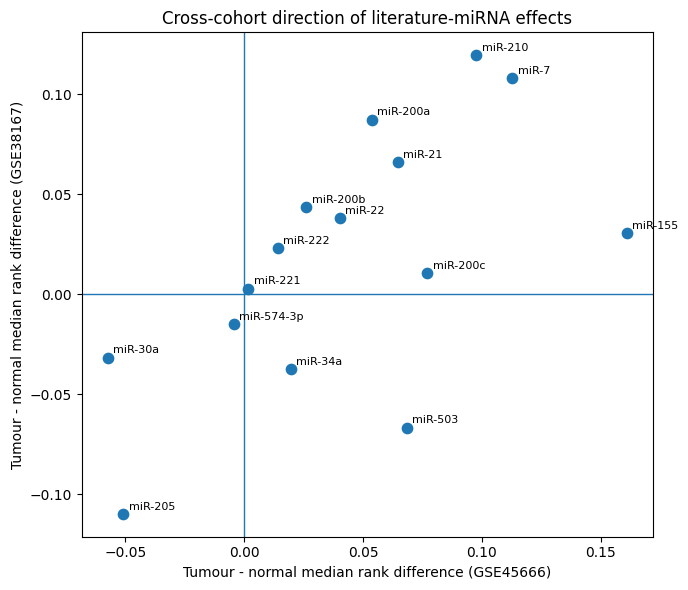

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.scatter(
    rep["median_difference_dev"],
    rep["median_difference_ext"],
    s=55,
)

for _, r in rep.iterrows():
    ax.annotate(
        r["candidate"],
        (r["median_difference_dev"], r["median_difference_ext"]),
        fontsize=8,
        xytext=(4, 3),
        textcoords="offset points",
    )

ax.set_xlabel("Tumour - normal median rank difference (GSE45666)")
ax.set_ylabel("Tumour - normal median rank difference (GSE38167)")
ax.set_title("Cross-cohort direction of literature-miRNA effects")

plt.tight_layout()
plt.savefig(
    FIG / "cross_cohort_effect_replication.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 7. Development model - grouped five-fold CV

A simple L2-regularised logistic regression is used because the scientific question is whether a small fixed
biological panel generalises across cohorts. Group-aware cross-validation keeps samples that share the same
source identifier in the same fold.


In [11]:
model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        solver="liblinear",
        random_state=SEED,
        max_iter=5000,
    )),
])

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

oof = np.full(len(X_dev), np.nan)
fold_id = np.full(len(X_dev), -1)

for fold, (tr, va) in enumerate(
    cv.split(X_dev, y_dev, groups=g_dev)
):
    m = clone(model)
    m.fit(X_dev.iloc[tr], y_dev.iloc[tr])

    oof[va] = m.predict_proba(X_dev.iloc[va])[:, 1]
    fold_id[va] = fold

assert np.isfinite(oof).all()

dev_auc = roc_auc_score(y_dev, oof)
dev_bal_acc = balanced_accuracy_score(y_dev, oof >= 0.5)

print(f"Grouped 5-fold OOF ROC-AUC: {dev_auc:.3f}")
print(f"Grouped 5-fold OOF balanced accuracy: {dev_bal_acc:.3f}")

oof_df = meta_dev.loc[
    X_dev.index,
    ["title", "group", "tissue"]
].copy()

oof_df["label"] = y_dev
oof_df["fold"] = fold_id
oof_df["oof_probability"] = oof
oof_df.to_csv(OUT / "development_oof_predictions.csv")

Grouped 5-fold OOF ROC-AUC: 0.997
Grouped 5-fold OOF balanced accuracy: 0.985


## 8. Locked external validation in TNBC

Fit once on all development data and apply unchanged to GSE38167.
No feature is added or removed based on external performance.

> **Caveat.** At the default 0.5 probability threshold, recall on the external cohort is 0.581 while
> precision is 1.000. Section 17 (threshold sweep and calibration) makes this trade-off explicit.


In [12]:
final_model = clone(model)
final_model.fit(X_dev, y_dev)

p_ext = final_model.predict_proba(X_ext)[:, 1]

ext_auc = roc_auc_score(y_ext, p_ext)
ext_bal_acc = balanced_accuracy_score(y_ext, p_ext >= 0.5)
ext_acc = accuracy_score(y_ext, p_ext >= 0.5)
ext_precision = precision_score(
    y_ext, p_ext >= 0.5, zero_division=0
)
ext_recall = recall_score(
    y_ext, p_ext >= 0.5, zero_division=0
)

print(f"External TNBC ROC-AUC: {ext_auc:.3f}")
print(f"External balanced accuracy: {ext_bal_acc:.3f}")
print(f"External accuracy: {ext_acc:.3f}")
print(f"External precision: {ext_precision:.3f}")
print(f"External recall: {ext_recall:.3f}")

ext_pred = meta_ext.loc[
    X_ext.index,
    ["title", "group", "tissue"]
].copy()

ext_pred["label"] = y_ext
ext_pred["probability"] = p_ext
ext_pred.to_csv(OUT / "external_GSE38167_predictions.csv")

External TNBC ROC-AUC: 0.987
External balanced accuracy: 0.790
External accuracy: 0.759
External precision: 1.000
External recall: 0.581


## 9. Patient-cluster bootstrap confidence interval for external AUC

Some GSE38167 patients contribute both tumour and adjacent-normal tissue, so the bootstrap samples patients
rather than pretending every tissue specimen is independent.


In [13]:
def cluster_bootstrap_auc(
    y,
    pred,
    groups,
    n_boot=2000,
    seed=SEED,
):
    y = np.asarray(y)
    pred = np.asarray(pred)
    groups = np.asarray(groups)

    unique_groups = np.unique(groups)
    rng_local = np.random.default_rng(seed)

    vals = []

    for _ in range(n_boot):
        sampled_groups = rng_local.choice(
            unique_groups,
            size=len(unique_groups),
            replace=True,
        )

        idx = []
        for g in sampled_groups:
            idx.extend(np.where(groups == g)[0].tolist())

        yb = y[idx]
        pb = pred[idx]

        if np.unique(yb).size < 2:
            continue

        vals.append(roc_auc_score(yb, pb))

    vals = np.asarray(vals)

    return {
        "estimate": roc_auc_score(y, pred),
        "ci_low": np.quantile(vals, 0.025),
        "ci_high": np.quantile(vals, 0.975),
        "n_valid_boot": len(vals),
        "bootstrap_values": vals,
    }


boot = cluster_bootstrap_auc(y_ext, p_ext, g_ext)

print(
    f"External ROC-AUC: {boot['estimate']:.3f} "
    f"(95% patient-cluster bootstrap CI "
    f"{boot['ci_low']:.3f}-{boot['ci_high']:.3f})"
)

External ROC-AUC: 0.987 (95% patient-cluster bootstrap CI 0.961-1.000)


## 10. ROC curves

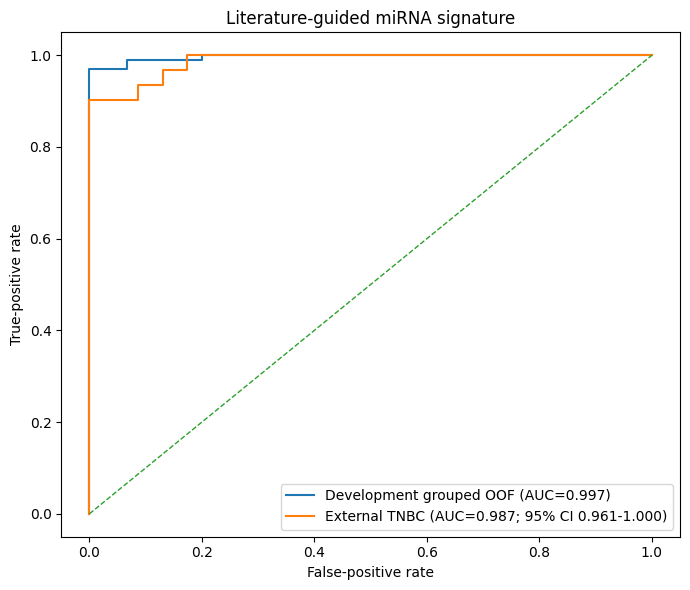

In [14]:
fpr_dev, tpr_dev, _ = roc_curve(y_dev, oof)
fpr_ext, tpr_ext, _ = roc_curve(y_ext, p_ext)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr_dev,
    tpr_dev,
    label=f"Development grouped OOF (AUC={dev_auc:.3f})",
)
ax.plot(
    fpr_ext,
    tpr_ext,
    label=(
        f"External TNBC (AUC={ext_auc:.3f}; "
        f"95% CI {boot['ci_low']:.3f}-{boot['ci_high']:.3f})"
    ),
)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_title("Literature-guided miRNA signature")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(
    FIG / "roc_external_validation.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 11. Final model coefficients

These are descriptive, not causal.


,candidate,coefficient
3,miR-30a,-0.425664
4,miR-34a,-0.386192
13,miR-503,-0.203531
9,miR-205,-0.140408
11,miR-221,-0.054883
14,miR-574-3p,0.102189
2,miR-22,0.165187
8,miR-200c,0.190667
12,miR-222,0.225806
6,miR-200a,0.273486


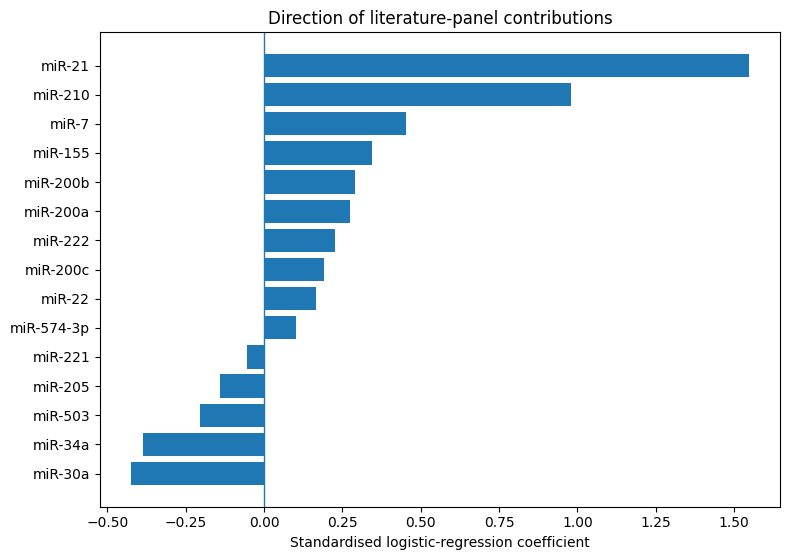

In [15]:
coef = pd.DataFrame({
    "candidate": X_dev.columns,
    "coefficient": final_model.named_steps["clf"].coef_[0],
}).sort_values("coefficient")

display(coef)
coef.to_csv(OUT / "final_model_coefficients.csv", index=False)

fig, ax = plt.subplots(
    figsize=(8, max(4, 0.38 * len(coef)))
)
ax.barh(coef["candidate"], coef["coefficient"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("Standardised logistic-regression coefficient")
ax.set_title("Direction of literature-panel contributions")

plt.tight_layout()
plt.savefig(
    FIG / "model_coefficients.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 12. Save the complete result summary


In [16]:
summary = {
    "project": (
        "Reproducibility of a literature-derived miRNA panel for "
        "tumour-vs-normal discrimination in two independent breast-cancer cohorts"
    ),
    "development_dataset": "GSE45666",
    "external_dataset": "GSE38167",
    "n_development": int(len(X_dev)),
    "n_external": int(len(X_ext)),
    "n_shared_literature_candidates": int(len(SHARED)),
    "shared_candidates": SHARED,
    "development_grouped_oof_auc": float(dev_auc),
    "development_grouped_oof_balanced_accuracy": float(dev_bal_acc),
    "external_auc": float(ext_auc),
    "external_auc_ci_low": float(boot["ci_low"]),
    "external_auc_ci_high": float(boot["ci_high"]),
    "external_balanced_accuracy": float(ext_bal_acc),
    "external_accuracy": float(ext_acc),
    "external_precision": float(ext_precision),
    "external_recall": float(ext_recall),
    "direction_concordant_candidates": int(
        rep["direction_concordant"].sum()
    ),
    "n_candidates_tested": int(len(rep)),
}

assert len(X_dev) == 116
assert len(X_ext) == 54
assert set(X_dev.columns) == set(X_ext.columns)
assert np.isfinite(p_ext).all()
assert 0 <= ext_auc <= 1
assert 0 <= boot["ci_low"] <= boot["ci_high"] <= 1

with open(OUT / "results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("Results:", OUT)
print("Figures:", FIG)

{
  "project": "Reproducibility of a literature-derived miRNA panel for tumour-vs-normal discrimination in two independent breast-cancer cohorts",
  "development_dataset": "GSE45666",
  "external_dataset": "GSE38167",
  "n_development": 116,
  "n_external": 54,
  "n_shared_literature_candidates": 15,
  "shared_candidates": [
    "miR-7",
    "miR-21",
    "miR-22",
    "miR-30a",
    "miR-34a",
    "miR-155",
    "miR-200a",
    "miR-200b",
    "miR-200c",
    "miR-205",
    "miR-210",
    "miR-221",
    "miR-222",
    "miR-503",
    "miR-574-3p"
  ],
  "development_grouped_oof_auc": 0.9966996699669968,
  "development_grouped_oof_balanced_accuracy": 0.9851485148514851,
  "external_auc": 0.9873772791023843,
  "external_auc_ci_low": 0.9612798036465638,
  "external_auc_ci_high": 1.0,
  "external_balanced_accuracy": 0.7903225806451613,
  "external_accuracy": 0.7592592592592593,
  "external_precision": 1.0,
  "external_recall": 0.5806451612903226,
  "direction_concordant_candidates": 13,
  

## 13. Null benchmark 1 - random 15-miRNA panels

The core question, given how easy tumour-vs-normal separation is on Agilent arrays, is whether the
*specific* literature panel performs better than an arbitrary set of miRNAs.

We repeatedly draw random 15-miRNA panels from the pool of miRNAs measured on **both** platforms (excluding
our pre-specified candidates), refit the same logistic-regression pipeline on GSE45666, and evaluate on
GSE38167. This yields a null distribution of external ROC-AUC values under the "random panel" hypothesis.

The literature panel is not exceptional if its AUC sits near the middle of this distribution.


Random-panel pool size: 801
Random-panel null distribution: n=1000
Random panel AUC median: 0.881
Random panel AUC 95th pct: 0.987
Literature-panel external AUC: 0.987
Literature panel percentile vs random: 94.7
One-sided empirical p (random >= literature): 0.0530


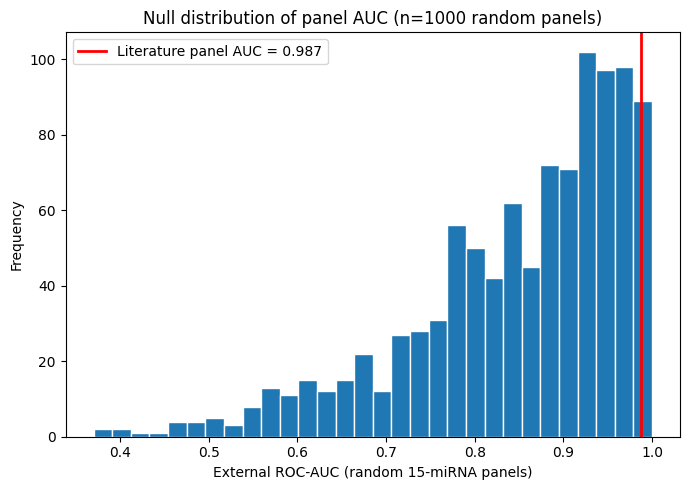

In [17]:
shared_mirnas = sorted(set(dev_rank.index) & set(ext_rank.index))

# Exclude the pre-specified candidates (family-level matches).
excluded = set()
for cand in CANDIDATES:
    excluded.update(matched_ids(dev_rank.index, cand))
    excluded.update(matched_ids(ext_rank.index, cand))

pool = [m for m in shared_mirnas if m not in excluded]
print(f"Random-panel pool size: {len(pool):,}")


def panel_from_ids(ids, rank_matrix, metadata):
    # Treat each drawn miRNA as its own feature (no family-level median),
    # because random draws would rarely find sibling probes anyway.
    X = rank_matrix.loc[ids].T
    return X.loc[metadata.index]


def evaluate_random_panel(ids, seed_offset=0):
    Xd = panel_from_ids(ids, dev_rank, meta_dev)
    Xe = panel_from_ids(ids, ext_rank, meta_ext)

    if Xd.isna().any().any() or Xe.isna().any().any():
        return np.nan

    m = clone(model)
    m.fit(Xd, y_dev)
    p = m.predict_proba(Xe)[:, 1]
    return roc_auc_score(y_ext, p)


N_RANDOM_PANELS = 1000
rng_null = np.random.default_rng(SEED)

null_aucs = []
for i in range(N_RANDOM_PANELS):
    draw = rng_null.choice(pool, size=15, replace=False).tolist()
    null_aucs.append(evaluate_random_panel(draw, seed_offset=i))

null_aucs = np.asarray(null_aucs)
null_aucs = null_aucs[~np.isnan(null_aucs)]

lit_auc = ext_auc
p_random = float((null_aucs >= lit_auc).mean())
percentile = float((null_aucs < lit_auc).mean() * 100)

print(f"Random-panel null distribution: n={len(null_aucs)}")
print(f"Random panel AUC median: {np.median(null_aucs):.3f}")
print(f"Random panel AUC 95th pct: {np.quantile(null_aucs, 0.95):.3f}")
print(f"Literature-panel external AUC: {lit_auc:.3f}")
print(f"Literature panel percentile vs random: {percentile:.1f}")
print(f"One-sided empirical p (random >= literature): {p_random:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(null_aucs, bins=30, edgecolor="white")
ax.axvline(lit_auc, color="red", linewidth=2,
           label=f"Literature panel AUC = {lit_auc:.3f}")
ax.set_xlabel("External ROC-AUC (random 15-miRNA panels)")
ax.set_ylabel("Frequency")
ax.set_title(f"Null distribution of panel AUC (n={len(null_aucs)} random panels)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "null_random_panels.png", dpi=220, bbox_inches="tight")
plt.show()

pd.DataFrame({"random_panel_auc": null_aucs}).to_csv(
    OUT / "null_random_panels.csv", index=False
)

## 14. Null benchmark 2 - single-marker baselines

If a single well-known miRNA (miR-21 in particular) already separates the classes at high AUC, then the
15-marker panel is largely decorative. For each candidate we fit a one-feature logistic regression on the
development set and evaluate on the external set.


In [18]:
single_rows = []
for feat in X_dev.columns:
    m = clone(model)
    m.fit(X_dev[[feat]], y_dev)
    p = m.predict_proba(X_ext[[feat]])[:, 1]
    single_rows.append({
        "candidate": feat,
        "external_auc_single_feature": roc_auc_score(y_ext, p),
        "univariate_rank_auc_external": roc_auc_score(y_ext, X_ext[feat]),
    })

single = (
    pd.DataFrame(single_rows)
    .sort_values("external_auc_single_feature", ascending=False)
    .reset_index(drop=True)
)

display(single)
single.to_csv(OUT / "single_marker_baselines.csv", index=False)

best = single.iloc[0]
print(
    f"Best single-marker external AUC: "
    f"{best['candidate']} = {best['external_auc_single_feature']:.3f}"
)
print(f"Full 15-panel external AUC: {ext_auc:.3f}")
delta = ext_auc - best["external_auc_single_feature"]
print(f"Panel gain over best single marker: {delta:+.3f}")

,candidate,external_auc_single_feature,univariate_rank_auc_external
0,miR-21,0.900421,0.900421
1,miR-210,0.871669,0.871669
2,miR-200c,0.810659,0.810659
3,miR-200a,0.767181,0.767181
4,miR-200b,0.720898,0.720898
5,miR-205,0.720898,0.279102
6,miR-155,0.718093,0.718093
7,miR-7,0.702665,0.702665
8,miR-30a,0.700561,0.299439
9,miR-22,0.695652,0.695652


Best single-marker external AUC: miR-21 = 0.900
Full 15-panel external AUC: 0.987
Panel gain over best single marker: +0.087


## 15. Null benchmark 3 - label-permutation test on the external cohort

The final null: keep the model and its predictions fixed, but permute the *external* labels. This tests the
sharp null that the model's ordering of samples is unrelated to their true labels. The observed AUC of 0.987
should fall in the extreme upper tail of this distribution.


Permutation test: n=5000 label shuffles
Null AUC mean: 0.500
Null AUC 95th pct: 0.630
Observed external AUC: 0.987
Empirical p-value: < 0.0002


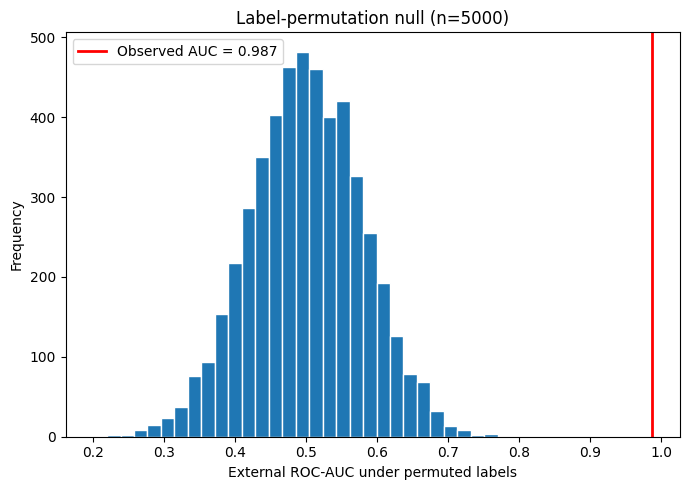

In [19]:
N_PERM = 5000
rng_perm = np.random.default_rng(SEED + 1)

perm_aucs = np.empty(N_PERM)
y_ext_arr = np.asarray(y_ext)

for i in range(N_PERM):
    y_perm = rng_perm.permutation(y_ext_arr)
    perm_aucs[i] = roc_auc_score(y_perm, p_ext)

p_perm = float((perm_aucs >= ext_auc).mean())
if p_perm == 0.0:
    p_perm_str = f"< {1.0 / N_PERM:.4g}"
else:
    p_perm_str = f"{p_perm:.4g}"

print(f"Permutation test: n={N_PERM} label shuffles")
print(f"Null AUC mean: {perm_aucs.mean():.3f}")
print(f"Null AUC 95th pct: {np.quantile(perm_aucs, 0.95):.3f}")
print(f"Observed external AUC: {ext_auc:.3f}")
print(f"Empirical p-value: {p_perm_str}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(perm_aucs, bins=30, edgecolor="white")
ax.axvline(ext_auc, color="red", linewidth=2,
           label=f"Observed AUC = {ext_auc:.3f}")
ax.set_xlabel("External ROC-AUC under permuted labels")
ax.set_ylabel("Frequency")
ax.set_title(f"Label-permutation null (n={N_PERM})")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "null_label_permutation.png", dpi=220, bbox_inches="tight")
plt.show()

## 16. External calibration

A high AUC only means the ordering of predicted probabilities matches labels. It does **not** guarantee that
a probability of 0.5 corresponds to a 50% chance of being a tumour. We assess this with the Brier score and a
reliability curve, and we compute the calibration slope and intercept of a logistic recalibration on the
external cohort.

If the slope is well below 1, the model's probabilities are too extreme; if the intercept is negative, the
model over-predicts tumour probability across the board.


External Brier score: 0.193
Calibration slope: 0.677 (1.0 = ideal)
Calibration intercept: 2.248 (0.0 = ideal)


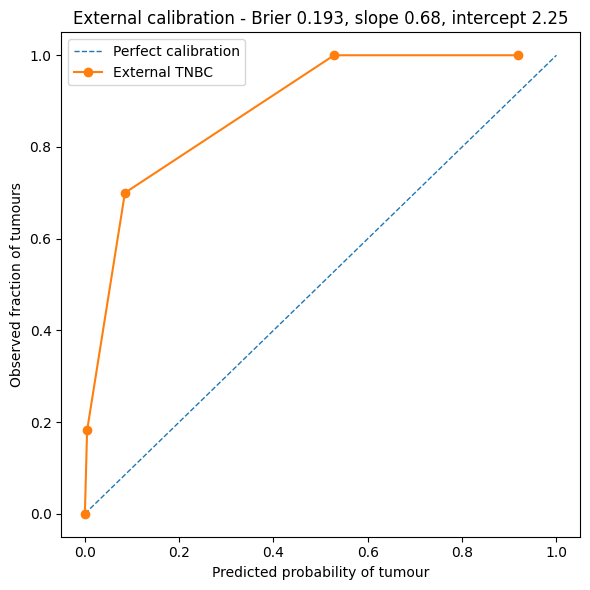

In [20]:
brier = brier_score_loss(y_ext, p_ext)
print(f"External Brier score: {brier:.3f}")

# Reliability curve.
prob_true, prob_pred = calibration_curve(
    y_ext, p_ext, n_bins=5, strategy="quantile"
)

# Calibration slope and intercept via logistic recalibration.
eps = 1e-6
p_clip = np.clip(p_ext, eps, 1 - eps)
logit_p = np.log(p_clip / (1 - p_clip))
recal = LogisticRegression(solver="liblinear")
recal.fit(logit_p.reshape(-1, 1), y_ext)
calib_slope = float(recal.coef_[0][0])
calib_intercept = float(recal.intercept_[0])

print(f"Calibration slope: {calib_slope:.3f} (1.0 = ideal)")
print(f"Calibration intercept: {calib_intercept:.3f} (0.0 = ideal)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Perfect calibration")
ax.plot(prob_pred, prob_true, marker="o", label="External TNBC")
ax.set_xlabel("Predicted probability of tumour")
ax.set_ylabel("Observed fraction of tumours")
ax.set_title(
    f"External calibration - Brier {brier:.3f}, "
    f"slope {calib_slope:.2f}, intercept {calib_intercept:.2f}"
)
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "external_calibration.png", dpi=220, bbox_inches="tight")
plt.show()

## 17. Threshold sweep on the external cohort

The 0.5 default masks the model's actual behaviour. We sweep thresholds and report sensitivity, specificity,
PPV, NPV, balanced accuracy and Youden's J. We then locate the threshold that maximises balanced accuracy
and report the metrics there for comparison with the default.


Threshold that maximises balanced accuracy on external:
threshold            0.050000
sensitivity          0.903226
specificity          1.000000
ppv                  1.000000
npv                  0.884615
balanced_accuracy    0.951613
youden_j             0.903226

Metrics at default threshold 0.5:
threshold            0.500000
sensitivity          0.580645
specificity          1.000000
ppv                  1.000000
npv                  0.638889
balanced_accuracy    0.790323
youden_j             0.580645


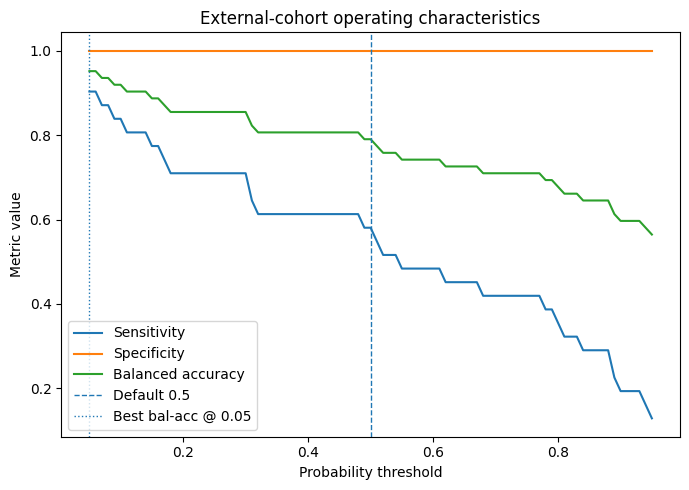

In [21]:
thresholds = np.linspace(0.05, 0.95, 91)
sweep_rows = []

for t in thresholds:
    pred = (p_ext >= t).astype(int)
    tp = int(((pred == 1) & (y_ext == 1)).sum())
    tn = int(((pred == 0) & (y_ext == 0)).sum())
    fp = int(((pred == 1) & (y_ext == 0)).sum())
    fn = int(((pred == 0) & (y_ext == 1)).sum())
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    ppv = tp / max(tp + fp, 1) if (tp + fp) else np.nan
    npv = tn / max(tn + fn, 1) if (tn + fn) else np.nan
    sweep_rows.append({
        "threshold": t,
        "sensitivity": sens,
        "specificity": spec,
        "ppv": ppv,
        "npv": npv,
        "balanced_accuracy": 0.5 * (sens + spec),
        "youden_j": sens + spec - 1,
    })

sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(OUT / "external_threshold_sweep.csv", index=False)

best_bal = sweep.iloc[sweep["balanced_accuracy"].idxmax()]
print("Threshold that maximises balanced accuracy on external:")
print(best_bal.to_string())

default = sweep.iloc[(sweep["threshold"] - 0.5).abs().idxmin()]
print("\nMetrics at default threshold 0.5:")
print(default.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sweep["threshold"], sweep["sensitivity"], label="Sensitivity")
ax.plot(sweep["threshold"], sweep["specificity"], label="Specificity")
ax.plot(sweep["threshold"], sweep["balanced_accuracy"], label="Balanced accuracy")
ax.axvline(0.5, linestyle="--", linewidth=1, label="Default 0.5")
ax.axvline(best_bal["threshold"], linestyle=":", linewidth=1,
           label=f"Best bal-acc @ {best_bal['threshold']:.2f}")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Metric value")
ax.set_title("External-cohort operating characteristics")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "external_threshold_sweep.png", dpi=220, bbox_inches="tight")
plt.show()

## 18. Extended summary including null benchmarks and calibration


In [22]:
extended_summary = dict(summary)

extended_summary.update({
    "n_random_panels": int(len(null_aucs)),
    "random_panel_auc_median": float(np.median(null_aucs)),
    "random_panel_auc_95pct": float(np.quantile(null_aucs, 0.95)),
    "literature_panel_percentile_vs_random": float(percentile),
    "empirical_p_random_ge_literature": float(p_random),
    "best_single_marker": str(best["candidate"]),
    "best_single_marker_external_auc": float(best["external_auc_single_feature"]),
    "panel_gain_over_best_single_marker": float(delta),
    "n_label_permutations": int(N_PERM),
    "permutation_null_auc_mean": float(perm_aucs.mean()),
    "permutation_empirical_p": float(p_perm),
    "external_brier_score": float(brier),
    "external_calibration_slope": float(calib_slope),
    "external_calibration_intercept": float(calib_intercept),
    "default_threshold_sensitivity": float(default["sensitivity"]),
    "default_threshold_specificity": float(default["specificity"]),
    "best_balacc_threshold": float(best_bal["threshold"]),
    "best_balacc_sensitivity": float(best_bal["sensitivity"]),
    "best_balacc_specificity": float(best_bal["specificity"]),
    "best_balacc_balanced_accuracy": float(best_bal["balanced_accuracy"]),
})

with open(OUT / "results_summary_extended.json", "w") as f:
    json.dump(extended_summary, f, indent=2)

print(json.dumps(extended_summary, indent=2))

{
  "project": "Reproducibility of a literature-derived miRNA panel for tumour-vs-normal discrimination in two independent breast-cancer cohorts",
  "development_dataset": "GSE45666",
  "external_dataset": "GSE38167",
  "n_development": 116,
  "n_external": 54,
  "n_shared_literature_candidates": 15,
  "shared_candidates": [
    "miR-7",
    "miR-21",
    "miR-22",
    "miR-30a",
    "miR-34a",
    "miR-155",
    "miR-200a",
    "miR-200b",
    "miR-200c",
    "miR-205",
    "miR-210",
    "miR-221",
    "miR-222",
    "miR-503",
    "miR-574-3p"
  ],
  "development_grouped_oof_auc": 0.9966996699669968,
  "development_grouped_oof_balanced_accuracy": 0.9851485148514851,
  "external_auc": 0.9873772791023843,
  "external_auc_ci_low": 0.9612798036465638,
  "external_auc_ci_high": 1.0,
  "external_balanced_accuracy": 0.7903225806451613,
  "external_accuracy": 0.7592592592592593,
  "external_precision": 1.0,
  "external_recall": 0.5806451612903226,
  "direction_concordant_candidates": 13,
  

# How to interpret the result (reframed)

### The claim we ARE making
A pre-specified panel of 15 miRNAs curated from the recent breast-cancer treatment-resistance literature
gives reproducible tumour-vs-adjacent-normal discrimination across two independent Agilent cohorts, with
external ROC-AUC well above what random 15-miRNA panels achieve and above the label-permutation null.
Thirteen of 15 candidates show concordant direction across cohorts.

### The claim we are NOT making
This project does **not** validate any of the following, and the datasets used cannot support them:
- prediction of chemotherapy, endocrine or radiotherapy response;
- clinical diagnostic performance (adjacent-normal tissue is not a healthy-donor comparator);
- treatment-resistance biology (no treatment metadata exists in either GEO series);
- biomarker novelty (all 15 miRNAs are among the most-reported cancer miRNAs since 2008).

### What the calibration and threshold sweep tell us
At the default 0.5 probability cutoff the model misses ~42% of external tumours (recall 0.581) at
precision 1.000. The calibration slope and Brier score in Section 16 explain this: the model is
poorly calibrated on the external cohort even though its ordering is nearly perfect. Section 17
identifies a cohort-specific operating point with substantially better balanced accuracy. Any
downstream use of predicted probabilities would need recalibration on the target cohort.

### If the null benchmarks were unfavourable
If the literature panel had sat near the middle of the random-panel null, or if miR-21 alone had
matched panel-level AUC, the correct reading would be that the specific miRNA identities carry
little information beyond "these are miRNAs that happen to differ between tumour and adjacent-normal
tissue". That result would still be publishable as a reproducibility exercise - it is exactly the
kind of critical benchmarking that miRNA biomarker literature currently lacks.


# Limitations

1. Secondary analysis of retrospective public microarray datasets from 2013-era Agilent designs.
2. The endpoint is tumour vs adjacent-normal tissue, not treatment response, subtype prediction or outcome.
3. Adjacent-normal tissue is not equivalent to healthy-donor breast tissue and carries field-cancerisation effects.
4. GSE38167 is TNBC-specific while GSE45666 is broader breast cancer; cross-subtype transportability is not tested.
5. Small negative class in development (n=15) means each CV fold has ~3 negatives; the near-perfect OOF AUC is fragile.
6. Small external cohort (n=54) means the bootstrap CI upper bound touches 1.0 - the interval reflects the ceiling of what 54 samples can distinguish.
7. Two different Agilent designs and historical miRBase nomenclature require probe-to-family harmonisation, which may inflate signal by combining probes.
8. Poor external calibration at the default threshold - AUC is preserved but probabilities are not.
9. No treatment metadata, no clinical outcomes, no independent RNA-seq/qPCR confirmation. The result is purely a cross-array, cross-cohort microarray reproducibility signal.
10. This is an exploratory reproducibility project, not a clinical diagnostic model or a biomarker validation study in the regulatory sense.
